# Annual Sea Level Rankings

```{glue:figure} SL_rankings
:align: center
```
In this notebook, we'll be creating a [table](SL_rankings_results) and a time series [plot](SL_rankings_timeseries) of sea level rankings at {glue:text}`station` from 1993-2024. Looking at extreme sea levels by ranking our top events helps us quickly put high and low water levels into historical context with relatively little coding effort.


## Setup

As with previous sections, we first need to import the necessary libraries, and establish our input/output directories. Note that this notebook is also largely a repeat of the [anomaly](notebooks/regional_and_local/SL_anomaly_annual.ipynb) notebook. 


In [1]:
# import necessary libraries
import numpy as np
import xarray as xr
import datetime as dt
from pathlib import Path
import pandas as pd
import os
import os.path as op
import sys

# data retrieval libraries
import requests
from urllib.request import urlretrieve #used for downloading files
import json
import copernicusmarine

# data processing libraries
from scipy import stats
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

from myst_nb import glue #used for figure numbering when exporting to LaTeX

sys.path.append("../../functions")
from data_downloaders import download_oni_index, download_uhslc_data
import importlib
import sea_level as sea_level_mod
importlib.reload(sea_level_mod)
from sea_level import (
    load_site_config,
    get_uhslc_datum,
    build_output_filename,
    build_site_tag,
    detect_enso_events,
    get_top_10_table,
    save_dict_json,
)


from sea_level_plotting import style_oni_based, make_plotly_figure_rankings, make_rankings_static_figure


Now we'll set up our input and output directories.


In [2]:
data_dir = Path('../../../data')
path_figs = "../../../matrix_cc/figures"
data_dir = Path(data_dir,'sea_level')
output_dir = data_dir 

# Create the output directory if it does not exist
output_dir.mkdir(exist_ok=True)
data_dir.mkdir(exist_ok=True)

# Also let's just make our figure sizes the same:
plt.rcParams['figure.figsize'] = [10, 4]  # Set a default figure size for the notebook


## Load Site Data Sources

Next, we'll access data from the UHSLC. The selected tide gauge uses the UHSLC ID from the site configuration. We will import the netcdf file into our current data directory, and take a peek at the dataset. We will also import the datums for this location. 


In [3]:
site_config_path = Path('../../data/sites/palau.json')
site_cfg = load_site_config(site_config_path)
site_name = site_cfg.get('site_name', 'Site')
site_lon = float(site_cfg.get('site_lon'))
site_lat = float(site_cfg.get('site_lat'))
uhslc_id = int(site_cfg.get('selected_uhslc_id'))

site_output_dir = Path('../../outputs') / build_site_tag(site_name, site_lon, site_lat)
site_output_dir.mkdir(parents=True, exist_ok=True)

# load pre-downloaded data
rsl = download_uhslc_data(data_dir, uhslc_id, 'hourly')
rsl


<xarray.Dataset> Size: 6MB
Dimensions:               (record_id: 1, time: 498513)
Coordinates:
  * time                  (time) datetime64[ns] 4MB 1969-05-18T15:00:00 ... 2...
  * record_id             (record_id) int64 8B 7
Data variables:
    sea_level             (record_id, time) float32 2MB ...
    lat                   (record_id) float32 4B ...
    lon                   (record_id) float32 4B ...
    station_name          (record_id) <U7 28B 'Malakal'
    station_country       (record_id) <U5 20B 'Palau'
    station_country_code  (record_id) float32 4B ...
    uhslc_id              (record_id) int16 2B ...
    gloss_id              (record_id) float32 4B ...
    ssc_id                (record_id) |S4 4B ...
    last_rq_date          (record_id) datetime64[ns] 8B ...
Attributes:
    title:                  UHSLC Fast Delivery Tide Gauge Data (hourly)
    ncei_template_version:  NCEI_NetCDF_TimeSeries_Orthogonal_Template_v2.0
    featureType:            timeSeries
    Conventions:            CF-1.6, ACDD-1.3
    date_created:           2026-05-05T14:36:55Z
    publisher_name:         University of Hawaii Sea Level Center (UHSLC)
    publisher_email:        philiprt@hawaii.edu, markm@soest.hawaii.edu
    publisher_url:          http://uhslc.soest.hawaii.edu
    summary:                The UHSLC assembles and distributes the Fast Deli...
    processing_level:       Fast Delivery (FD) data undergo a level 1 quality...
    acknowledgment:         The UHSLC Fast Delivery database is supported by ...

### Adjust to MHHW


In [4]:
# Adjust to MHHW in meters and update attributes
mhhw, _ = get_uhslc_datum(uhslc_id, 'MHHW')
sea_level_attrs = rsl['sea_level'].attrs.copy()
rsl['sea_level'] = (rsl['sea_level'] - mhhw) / 1000
rsl['sea_level'].attrs = sea_level_attrs  # restore all previous attributes
rsl['sea_level'].attrs['datum'] = 'MHHW (1983-2001)'  # update/add as needed
rsl['sea_level'].attrs['units'] = 'meters'


### Resample to monthly
For background plotting purposes. Here we'll extract the mean, min and max of the monthly MHHW sea level.


In [5]:
# get min and max for each month by resampling
rsl_monthly_min = rsl.resample(time='1ME').min()
rsl_monthly_max = rsl.resample(time='1ME').max()
rsl_monthly_mean = rsl.resample(time='1ME').mean()


### Build Rankings Table
This section computes the top 10 high and low hourly sea level values for the selected station.
To ensure unique events, maxima and minima are required to be separated by at least 3 days.


## Make a Table
We'll use the function we defined above to make a table of the top 10 ranked high and low water events. We'll add the ONI values to this table, which will come in handy later.


Note that because we started this analysis with hourly data, we may not be fully aligned with max/min statistics from other sources. Hourly data will dampen both the minima and maxima due to averaging. Note also that there are other extreme water level rankings that may be offset by a different MHHW datum. Here, we used the 1983-2001 NTDE, corresponding to the datum used most often by NOAA CO-OPS. 

```{margin}
For other ranking tables, check out the [NASA Flooding Analysis Tool](https://sealevel.nasa.gov/flooding-analysis-tool/observed-flooding?station-id=1612340) or the [Sea Level Calculator](https://coast.noaa.gov/sealevelcalculator/#/quickview/1612340/extremeWaterLevels&search=eyJhY3RpdmVQYWdlIjoicXVpY2t2aWV3IiwidGlkZVN0YXRpb25JZCI6MTYxMjM0MCwic2VsZWN0ZWRRdWlja1ZpZXciOiJleHRyZW1lV2F0ZXJMZXZlbHMiLCJ0aGVtZSI6ImRhcmsiLCJpc1F1aWNrU2VsZWN0QWN0aXZlIjpmYWxzZSwibWFwTG9jYXRpb24iOnsiY2VudGVyIjpbLTE1Ny44NjQ1MjgsMjEuMzAzMzMyOTk5OTk5OTk1XSwiem9vbSI6MTEuNX0sImFkZHJlc3MiOiJIb25vbHVsdSwgSEkiLCJzdGF0aW9uSXNTZWxlY3RlZCI6dHJ1ZSwiZ2xvYmFsTWVudVZhbHVlcyI6eyJkYXR1bSI6Ik1ISFciLCJ1bml0cyI6ImVuZ2xpc2giLCJkZWNhZGUiOiIyMDMwIiwidmxtIjowLjAwNDMzMDcxMDk5OTk5OTk5OSwidGhyZXNob2xkIjowLjk5NywicHJlRGVmVGhyZXNob2xkIjp7ImxhYmVsIjoiTk9TIE1pbm9yIiwidmFsdWUiOnsiZW5nbGlzaCI6MC45OTcsIm1ldHJpYyI6MC4zMDR9LCJwYXJhbSI6Im5vc19taW5vciJ9LCJkYXlzVGhyZXNob2xkIjpudWxsLCJkYXRhU291cmNlIjoiMjAyMiBUZWNoIFJlcG9ydCIsIm9mZnNldFllYXIiOiIyMDAwIiwic2NlbmFyaW8iOiJJbnRlcm1lZGlhdGUiLCJtc2xUaHJlc2hvbGRJbk1ldHJpYyI6MC42MzMsImNvbnZlcnRlZFZMTSI6MC4xMDk5OTk5OTk5OTk5OTk5OX0sImN1cnJlbnRTdGF0aW9uUHJvcGVydGllcyI6eyJuYW1lIjoiSG9ub2x1bHUsIEhJIiwic3RhdGlvbklEIjoxNjEyMzQwLCJxdiI6WzEsMiwzLDQsNV0sInNsUHJvamVjdGlvblJlZ2lvbk5BU0EiOiJQQUMiLCJiZWdpbkRhdGUiOiIxOTExIiwiZW5kRGF0ZSI6bnVsbCwic3RhdGlvbkxvbiI6LTE1Ny44NjQ1MjgsInN0YXRpb25MYXQiOjIxLjMwMzMzM30sIm5vc1RocmVzaG9sZExheWVyIjoibm9zLW1pbm9yIiwid2F0ZXJMZXZlbCI6IjAiLCJpc01hcEZ1bGwiOmZhbHNlLCJncmlkRGF0YSI6eyJjZWxsRXh0ZW50IjpbXSwiY2xpY2tlZENvb3JkcyI6bnVsbCwiZ3JpZE51bWJlciI6bnVsbCwiUFNNU0xfSUQiOm51bGwsInJlZ2lvbiI6bnVsbH0sImlzU29sb0dyaWRDZWxsIjpmYWxzZSwicmV0cmlldmVkVkxNVmFsdWUiOjAuMTA5OTk5OTk5OTk5OTk5OTksImlzR3JpZExheWVyRGlzcGxheWVkIjp0cnVlLCJzZWxlY3RlZEJhc2VtYXAiOiJzYXRlbGxpdGUiLCJxdjFMZWdlbmQiOnsidGgiOjEsImgiOjEsImloIjoxLCJpIjoxLCJpbCI6MSwibCI6MSwib2UiOjEsInViIjowfSwicXYyTGVnZW5kIjp7ImFkYXQiOjEsImgiOjAsImloIjowLCJpIjowLCJpbCI6MCwibCI6MCwiZCI6MX0sInF2M0xlZ2VuZCI6eyJ0aCI6MSwibXdsIjoxLCJ0UGVyIjoxLCJ0ZW5QZXIiOjEsImZQZXIiOjEsIm5uUGVyIjoxfSwicXY0TGVnZW5kIjp7Im1tIjoxLCJldFBlciI6MSwic1BlciI6MSwibW8iOjEsInJvIjoxLCJsciI6MX0sInF2NUxlZ2VuZCI6eyJkdCI6MSwiZmQiOjEsIm12IjoxLCJhc2MiOjF9LCJxdjVDaGFydEJMZWdlbmQiOnsidHdvUCI6MSwidGVuUCI6MSwiZmlmUCI6MSwibmluUCI6MX19)
```


In [6]:
station_name = str(rsl['station_name'].sel(record_id=uhslc_id).values)

top_10_table = get_top_10_table(rsl, uhslc_id)

station_name


'Malakal'

### Display by rank
Now we'll start to make the table a little more presentable by labeling the columns properly, and organizing events by rank.


In [7]:
# subdivide the data into two columns for max and min
# Filter out the 'max' and 'min' types into separate DataFrames
max_top_10 = top_10_table[top_10_table['type'] == 'max'].reset_index(drop=True)
min_top_10 = top_10_table[top_10_table['type'] == 'min'].reset_index(drop=True)

# make table of highest and lowest values by rank, with columns: rank, highest sea level (m), date, lowest sea level (m), date
top_10_display = pd.DataFrame({'Rank':max_top_10['rank'],
                             'Highest':max_top_10['sea level (m)'].apply(lambda x: float(f"{x:.3g}")),
                             'Highest Date':max_top_10['date'].dt.strftime('%Y-%m-%d %H:%M'),
                             'Highest ONI Mode':max_top_10['ONI Mode'],
                             'Lowest':min_top_10['sea level (m)'].apply(lambda x: float(f"{x:.3g}")),
                             'Lowest Date':min_top_10['date'].dt.strftime('%Y-%m-%d %H:%M'),
                             'Lowest ONI Mode':min_top_10['ONI Mode'],
                             'Zone': 'GMT',
                             'ONI max':max_top_10['ONI'],
                             'ONI min':min_top_10['ONI']})


(SL_rankings_results)=
### Style the table
Now we'll add some style. The table will be colored by the ONI, if the event is classified as an El Nino or La Nina.


In [8]:
top_10_display


,Rank,Highest,Highest Date,Highest ONI Mode,Lowest,Lowest Date,Lowest ONI Mode,Zone,ONI max,ONI min
0,1,0.705,2025-11-07 10:00,Neutral,-2.19,1992-01-19 17:00,El Nino,GMT,-0.55,1.63
1,2,0.625,2013-06-23 22:00,Neutral,-2.18,1986-12-31 17:00,El Nino,GMT,-0.35,1.23
2,3,0.613,2016-10-16 10:00,Neutral,-2.17,1982-12-31 18:00,El Nino,GMT,-0.64,2.18
3,4,0.589,2016-05-07 22:00,Neutral,-2.12,2002-12-04 17:00,El Nino,GMT,0.49,1.14
4,5,0.582,2011-09-29 11:00,La Nina,-2.11,1995-01-01 17:00,El Nino,GMT,-0.96,0.96
5,6,0.581,1998-10-07 11:00,La Nina,-2.11,1970-01-08 18:00,El Nino,GMT,-1.35,0.51
6,7,0.576,2011-03-21 23:00,La Nina,-2.10,2019-01-21 17:00,El Nino,GMT,-0.62,0.86
7,8,0.575,2024-10-19 11:00,Neutral,-2.10,1983-01-28 17:00,El Nino,GMT,-0.30,1.92
8,9,0.572,2021-03-29 23:00,La Nina,-2.10,1982-12-02 18:00,El Nino,GMT,-0.55,2.23
9,10,0.568,2025-09-23 11:00,Neutral,-2.10,1987-01-29 17:00,El Nino,GMT,-0.51,1.19


In [9]:
# # Normalize the ONI values
import matplotlib.colors as mcolors
norm = mcolors.Normalize(vmin=-3, vmax=3)

# Define the color maps
cmap = sns.color_palette('coolwarm', as_cmap=True)

# Define the table style
styles_col = [
    {'selector': 'th', 'props': [('border-bottom', '2px solid #000'), ('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': '.dataframe th:nth-child(3)', 'props': [('padding-right', '100px')]}]

# Apply the styling function to the DataFrame
top_10_d = top_10_display.style.                            apply(lambda row: style_oni_based(row, norm, cmap), axis=1).                            hide(subset=['Highest ONI Mode', 'Lowest ONI Mode','ONI max','ONI min'], axis=1).                            hide().                            set_table_attributes(styles_col)


# Display the styled DataFrame



top_10_csv_name = build_output_filename('SL_top_10_table', site_name, site_lon, site_lat, ext='csv')
# save table to output folder
top_10_display.to_csv(site_output_dir / top_10_csv_name, index=False)

rankings_records = top_10_display.to_dict(orient='records')
save_dict_json(
    {'site_name': site_name, 'uhslc_id': int(uhslc_id), 'records': rankings_records},
    site_output_dir,
    build_output_filename('SL_top_10_table', site_name, site_lon, site_lat, ext='json'),
)

top_10_d


Rank,Highest,Highest Date,Lowest,Lowest Date,Zone
1,0.705000,2025-11-07 10:00,-2.190000,1992-01-19 17:00,GMT
2,0.625000,2013-06-23 22:00,-2.180000,1986-12-31 17:00,GMT
3,0.613000,2016-10-16 10:00,-2.170000,1982-12-31 18:00,GMT
4,0.589000,2016-05-07 22:00,-2.120000,2002-12-04 17:00,GMT
5,0.582000,2011-09-29 11:00,-2.110000,1995-01-01 17:00,GMT
6,0.581000,1998-10-07 11:00,-2.110000,1970-01-08 18:00,GMT
7,0.576000,2011-03-21 23:00,-2.100000,2019-01-21 17:00,GMT
8,0.575000,2024-10-19 11:00,-2.100000,1983-01-28 17:00,GMT
9,0.572000,2021-03-29 23:00,-2.100000,1982-12-02 18:00,GMT
10,0.568000,2025-09-23 11:00,-2.100000,1987-01-29 17:00,GMT


In [10]:
#make this a pretty table with great_tables
from great_tables import GT, md, html

# replace all spaces with underscores in top_10_display column names
top_10_display.columns = top_10_display.columns.str.replace(' ', '_')

outFilename = build_output_filename('SL_top_10_table', site_name, site_lon, site_lat, ext='png')
outFilepath = site_output_dir / outFilename

# Convert the DataFrame to a great_table
(
    GT(top_10_display)
    .tab_header(title='Top 10 Sea Level Events', subtitle='Station: '+station_name)
    .tab_spanner(label='HIGHEST', columns=['Highest', 'Highest_Date', 'Highest_ONI_Mode'])
    .tab_spanner(label='LOWEST', columns=['Lowest', 'Lowest_Date', 'Lowest_ONI_Mode'])
    .cols_hide(columns=['ONI_max','ONI_min','Zone'])
    .cols_align('center')
    .cols_label(Highest=html('Water Level <br>(m, MHHW)'), Highest_Date='Date', Highest_ONI_Mode='ONI Mode',
                Lowest=html('Water Level <br>(m, MHHW)'), Lowest_Date='Date', Lowest_ONI_Mode='ONI Mode')
                .tab_source_note(source_note='Source: UHSLC Hourly Water Level, https://psl.noaa.gov/data/correlation/oni.data')
    #.save(outFilepath)
)


GT(_tbl_data=   Rank  Highest      Highest_Date Highest_ONI_Mode  Lowest       Lowest_Date  \
0     1    0.705  2025-11-07 10:00          Neutral   -2.19  1992-01-19 17:00   
1     2    0.625  2013-06-23 22:00          Neutral   -2.18  1986-12-31 17:00   
2     3    0.613  2016-10-16 10:00          Neutral   -2.17  1982-12-31 18:00   
3     4    0.589  2016-05-07 22:00          Neutral   -2.12  2002-12-04 17:00   
4     5    0.582  2011-09-29 11:00          La Nina   -2.11  1995-01-01 17:00   
5     6    0.581  1998-10-07 11:00          La Nina   -2.11  1970-01-08 18:00   
6     7    0.576  2011-03-21 23:00          La Nina   -2.10  2019-01-21 17:00   
7     8    0.575  2024-10-19 11:00          Neutral   -2.10  1983-01-28 17:00   
8     9    0.572  2021-03-29 23:00          La Nina   -2.10  1982-12-02 18:00   
9    10    0.568  2025-09-23 11:00          Neutral   -2.10  1987-01-29 17:00   

  Lowest_ONI_Mode Zone  ONI_max  ONI_min  
0         El Nino  GMT    -0.55     1.63  
1         El Nino  GMT    -0.35     1.23  
2         El Nino  GMT    -0.64     2.18  
3         El Nino  GMT     0.49     1.14  
4         El Nino  GMT    -0.96     0.96  
5         El Nino  GMT    -1.35     0.51  
6         El Nino  GMT    -0.62     0.86  
7         El Nino  GMT    -0.30     1.92  
8         El Nino  GMT    -0.55     2.23  
9         El Nino  GMT    -0.51     1.19  , _body=<great_tables._gt_data.Body object at 0x17b2835c0>, _boxhead=Boxhead([ColInfo(var='Rank', type=<ColInfoTypeEnum.default: 1>, column_label='Rank', column_align='center', column_width=None), ColInfo(var='Highest', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Water Level <br>(m, MHHW)'), column_align='center', column_width=None), ColInfo(var='Highest_Date', type=<ColInfoTypeEnum.default: 1>, column_label='Date', column_align='center', column_width=None), ColInfo(var='Highest_ONI_Mode', type=<ColInfoTypeEnum.default: 1>, column_label='ONI Mode', column_align='center', column_width=None), ColInfo(var='Lowest', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Water Level <br>(m, MHHW)'), column_align='center', column_width=None), ColInfo(var='Lowest_Date', type=<ColInfoTypeEnum.default: 1>, column_label='Date', column_align='center', column_width=None), ColInfo(var='Lowest_ONI_Mode', type=<ColInfoTypeEnum.default: 1>, column_label='ONI Mode', column_align='center', column_width=None), ColInfo(var='Zone', type=<ColInfoTypeEnum.hidden: 4>, column_label='Zone', column_align='center', column_width=None), ColInfo(var='ONI_max', type=<ColInfoTypeEnum.hidden: 4>, column_label='ONI_max', column_align='center', column_width=None), ColInfo(var='ONI_min', type=<ColInfoTypeEnum.hidden: 4>, column_label='ONI_min', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x17b5f3230>, _spanners=Spanners([SpannerInfo(spanner_id='HIGHEST', spanner_level=0, spanner_label='HIGHEST', spanner_units=None, spanner_pattern=None, vars=['Highest', 'Highest_Date', 'Highest_ONI_Mode'], built=None), SpannerInfo(spanner_id='LOWEST', spanner_level=0, spanner_label='LOWEST', spanner_units=None, spanner_pattern=None, vars=['Lowest', 'Lowest_Date', 'Lowest_ONI_Mode'], built=None)]), _heading=Heading(title='Top 10 Sea Level Events', subtitle='Station: Malakal', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x17bba5280>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x17bba52b0>, _source_notes=['Source: UHSLC Hourly Water Level, https://psl.noaa.gov/data/correlation/oni.data'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x17bba52e0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, catego

(SL_rankings_timeseries)=
## Make Timeseries Plots
Now we'll plot this data up in the time domain.

### Interactive Plots
This version is interactive. Bad for making pdf reports though.


A note: the plotly plot will not render in the jupyter book build, because the original data to build it is stored elsewhere (not on github). If you are replicating this notebook, it should work fine for you. In the meantime, the pre-built html is available.


In [11]:
figly = make_plotly_figure_rankings(
        rsl_monthly_mean,
        rsl_monthly_max,
        rsl_monthly_min,
        top_10_table,
        rsl,
        uhslc_id,
        station_name
)

# change size of the plot
# figly.update_layout(autosize=True)
figly.update_layout(width=800, height=500,autosize=False)
# save the figure to the output folder
figname = 'SL_top_10_plot_' + station_name + '.html'

# remove commas from figname
figname = figname.replace(', ','_')


figly


(static_plots)=
### Static Plots
Plotting them all so we can decide what to do with them. Click "show code cell output" to see all stations.


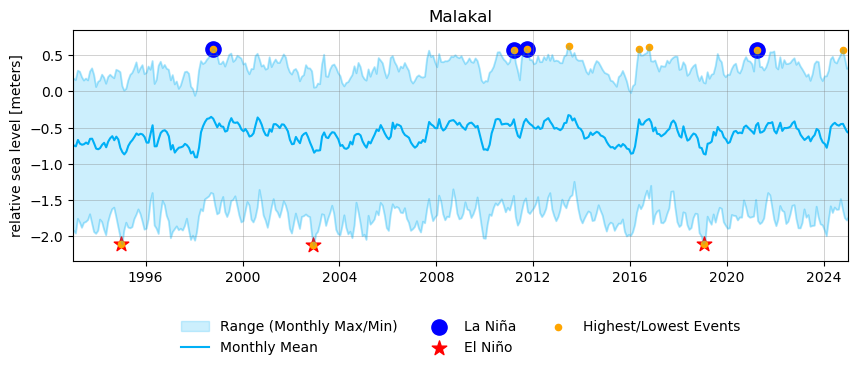

In [12]:
# static version
top_10_table = get_top_10_table(rsl, uhslc_id)
fig, ax = make_rankings_static_figure(
    rsl_monthly_mean=rsl_monthly_mean,
    rsl_monthly_max=rsl_monthly_max,
    rsl_monthly_min=rsl_monthly_min,
    top_10_table=top_10_table,
    rsl=rsl,
    uhslc_id=uhslc_id,
    station_name=station_name,
)

figname = 'SL_rankings_' + station_name.replace(' ', '_') + '.png'
fig.savefig(site_output_dir / build_output_filename(figname.replace('.png',''), site_name, site_lon, site_lat), dpi=300, bbox_inches='tight')

glue("SL_rankings", fig, display=False)


```{glue:figure} SL_rankings
:name: "SL_rankings"

This is a static version of the previous figure, which can be used for print (or static websites).
```


## Citations

```{bibliography}
:style: plain
:filter: docname in docnames
```
